# Análise Exploratória: Gastos dos Deputados Federais (Cota Parlamentar - CEAP)

**Contexto:** 2026 é ano de eleições gerais no Brasil (Presidente, Governadores, Senadores, Deputados Federais e Estaduais). Antes de olhar para os candidatos de 2026 (cujo registro só ocorre em agosto), faz sentido entender **como os atuais parlamentares usaram o dinheiro público durante o mandato** — a 57ª Legislatura (2023-2026).

**Fonte dos dados:** Portal de Dados Abertos da Câmara dos Deputados — Cota para o Exercício da Atividade Parlamentar (CEAP), que cobre despesas como passagens aéreas, combustível, manutenção de escritório, alimentação, divulgação parlamentar, entre outras.

> **Nota sobre deputados estaduais:** os gastos de deputados *estaduais* não têm uma base nacional unificada — cada Assembleia Legislativa estadual publica (ou não) seus próprios dados, em formatos diferentes. Por isso este projeto foca nos **deputados federais**, que têm uma base única, confiável e bem documentada. Dá pra expandir depois comparando com 1-2 assembleias estaduais específicas, se quiser.

**Perguntas que vamos responder:**
1. Qual foi o gasto total por ano na legislatura atual?
2. Quais categorias de despesa mais pesam no orçamento?
3. Como o gasto se distribui entre partidos e estados?
4. Quem são os deputados com maior e menor gasto?
5. Existe sazonalidade ou outliers relevantes?


## 1. Setup e Imports

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import zipfile
import io

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 5)


## 2. Download dos dados

Os dados são publicados por ano, em arquivos CSV compactados, no padrão:
`https://www.camara.leg.br/cotas/Ano-{ano}.csv.zip`

A legislatura atual (57ª) vai de 2023 a 2026, então baixamos esses 4 anos.

⚠️ **Importante:** esta célula precisa de acesso à internet ao site da Câmara. Se você rodar em um ambiente sem acesso (como um sandbox restrito), baixe manualmente os arquivos em
https://www2.camara.leg.br/transparencia/cota-para-exercicio-da-atividade-parlamentar/dados-abertos-cota-parlamentar
e ajuste a função `carregar_ano` para ler de um arquivo local.

In [9]:
ANOS = [2023, 2024, 2025, 2026]

def carregar_ano(ano: int) -> pd.DataFrame:
    url = f"https://www.camara.leg.br/cotas/Ano-{ano}.csv.zip"
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
        nome_arquivo = z.namelist()[0]
        with z.open(nome_arquivo) as f:
            conteudo = f.read()
    try:
        df = pd.read_csv(io.BytesIO(conteudo), sep=";", encoding="utf-8-sig", low_memory=False)
    except UnicodeDecodeError:
        df = pd.read_csv(io.BytesIO(conteudo), sep=";", encoding="latin-1", low_memory=False)
    df["anoreferencia"] = ano
    return df

dfs = []
for ano in ANOS:
    try:
        dfs.append(carregar_ano(ano))
        print(f"✅ {ano}: carregado")
    except Exception as e:
        print(f"⚠️ {ano}: erro ao baixar ({e})")

gastos = pd.concat(dfs, ignore_index=True)

def limpar_nome_coluna(c):
    c = c.strip().replace("ï»¿", "").lstrip("\ufeff").strip('"').strip("'")
    return c.lower()

gastos.columns = [limpar_nome_coluna(c) for c in gastos.columns]
print(f"\nTotal de registros: {len(gastos):,}")
print(f"Colunas disponíveis: {list(gastos.columns)}")

✅ 2023: carregado
✅ 2024: carregado
✅ 2025: carregado
✅ 2026: carregado

Total de registros: 748,828
Colunas disponíveis: ['txnomeparlamentar', 'cpf', 'idecadastro', 'nucarteiraparlamentar', 'nulegislatura', 'sguf', 'sgpartido', 'codlegislatura', 'numsubcota', 'txtdescricao', 'numespecificacaosubcota', 'txtdescricaoespecificacao', 'txtfornecedor', 'txtcnpjcpf', 'txtnumero', 'indtipodocumento', 'datemissao', 'vlrdocumento', 'vlrglosa', 'vlrliquido', 'nummes', 'numano', 'numparcela', 'txtpassageiro', 'txttrecho', 'numlote', 'numressarcimento', 'datpagamentorestituicao', 'vlrrestituicao', 'nudeputadoid', 'idedocumento', 'urldocumento', 'anoreferencia']


## 3. Limpeza e seleção de colunas

In [10]:
colunas_uteis = [
    "txnomeparlamentar", "sgpartido", "sguf", "nulegislatura",
    "txtdescricao", "txtfornecedor", "txtcnpjcpf",
    "datemissao", "nummes", "numano", "vlrdocumento", "vlrglosa", "vlrliquido",
    "anoreferencia"
]
colunas_existentes = [c for c in colunas_uteis if c in gastos.columns]
faltando = [c for c in colunas_uteis if c not in gastos.columns]
if faltando:
    print(f"⚠️ Colunas não encontradas: {faltando}")

gastos = gastos[colunas_existentes].copy()
gastos["vlrliquido"] = pd.to_numeric(gastos["vlrliquido"], errors="coerce")
gastos["datemissao"] = pd.to_datetime(gastos["datemissao"], errors="coerce")
gastos = gastos[gastos["vlrliquido"].notna() & (gastos["vlrliquido"] > 0)]

print(gastos.shape)
gastos.head()

(721023, 14)


,txnomeparlamentar,sgpartido,sguf,nulegislatura,txtdescricao,txtfornecedor,txtcnpjcpf,datemissao,nummes,numano,vlrdocumento,vlrglosa,vlrliquido,anoreferencia
0,LID.GOV-CD,NaN,NaN,2023,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,AMORETTO CAFES EXPRESSO LTDA,085.324.290/0013-1,2023-02-07,2,2023,899.0,0.0,899.0,2023
1,LID.GOV-CD,NaN,NaN,2023,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,AMORETTO CAFES EXPRESSO LTDA,085.324.290/0013-1,2023-06-06,6,2023,899.0,0.0,899.0,2023
2,LID.GOV-CD,NaN,NaN,2023,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,AMORETTO CAFES EXPRESSO LTDA,085.324.290/0013-1,2023-07-12,7,2023,899.0,0.0,899.0,2023
3,LID.GOV-CD,NaN,NaN,2023,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,AMORETTO CAFES EXPRESSO LTDA,085.324.290/0013-1,2023-08-03,8,2023,899.0,0.0,899.0,2023
4,LID.GOV-CD,NaN,NaN,2023,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,AMORETTO CAFES EXPRESSO LTDA,085.324.290/0013-1,2023-09-12,9,2023,899.0,0.0,899.0,2023


## 4. Visão geral

Gasto total, número de deputados únicos e estatísticas descritivas do valor das despesas.

In [11]:
print(f"Gasto total no período: R$ {gastos['vlrliquido'].sum():,.2f}")
print(f"Número de deputados únicos: {gastos['txnomeparlamentar'].nunique()}")
print(f"Número de notas/documentos: {len(gastos):,}")

gastos["vlrliquido"].describe()

Gasto total no período: R$ 874,300,511.28
Número de deputados únicos: 869
Número de notas/documentos: 721,023


,vlrliquido
count,721023.000000
mean,1212.583387
std,3188.254946
min,0.010000
25%,107.290000
50%,260.000000
75%,1058.075000
max,184428.000000


## 5. Gasto total por ano

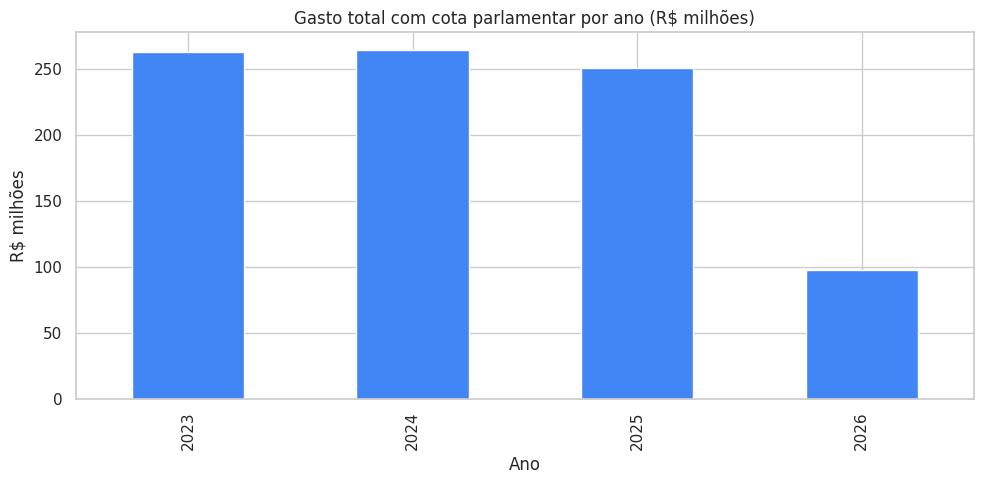

In [12]:
gasto_por_ano = gastos.groupby("anoreferencia")["vlrliquido"].sum() / 1_000_000

ax = gasto_por_ano.plot(kind="bar", color="#4285F4")
ax.set_title("Gasto total com cota parlamentar por ano (R$ milhões)")
ax.set_xlabel("Ano")
ax.set_ylabel("R$ milhões")
plt.tight_layout()
plt.show()

## 6. Top categorias de despesa

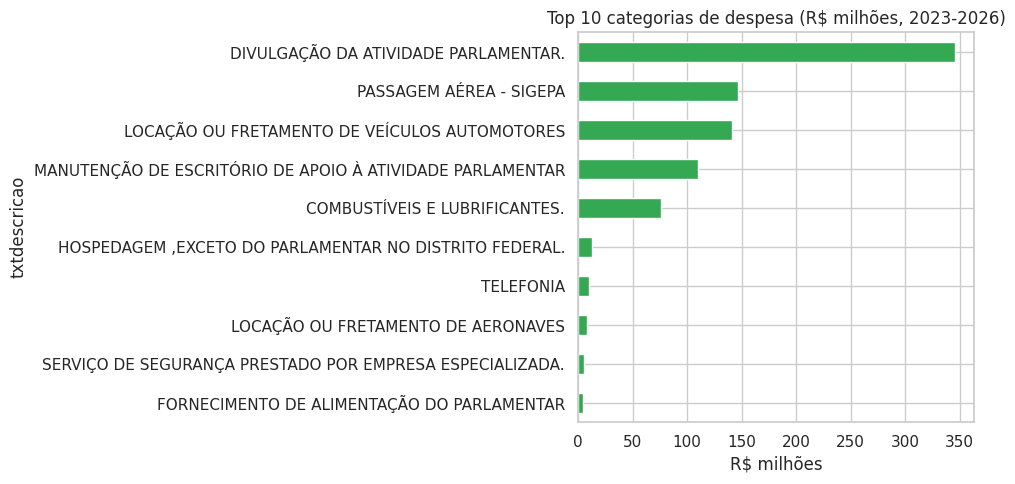

In [13]:
top_categorias = (
    gastos.groupby("txtdescricao")["vlrliquido"]
    .sum()
    .sort_values(ascending=False)
    .head(10) / 1_000_000
)

ax = top_categorias.sort_values().plot(kind="barh", color="#34A853")
ax.set_title("Top 10 categorias de despesa (R$ milhões, 2023-2026)")
ax.set_xlabel("R$ milhões")
plt.tight_layout()
plt.show()


## 7. Gasto por partido

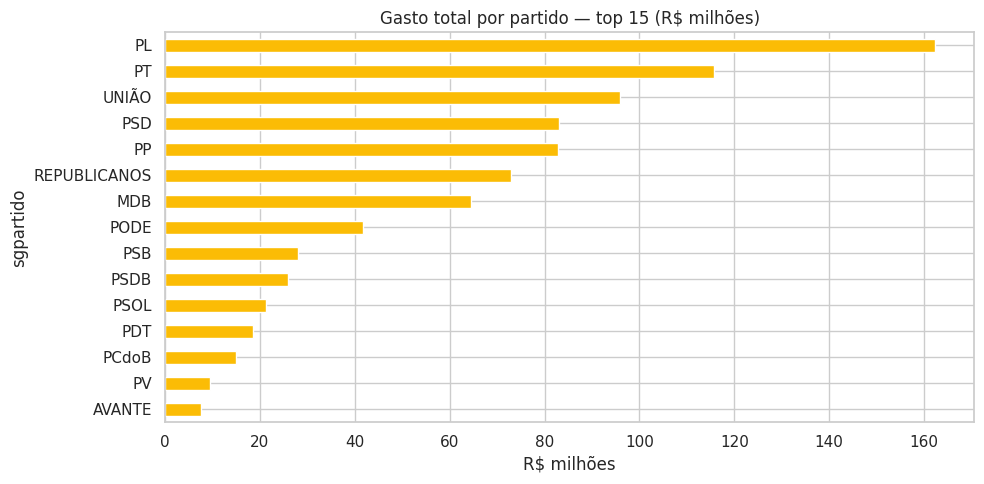

In [14]:
gasto_partido = (
    gastos.groupby("sgpartido")["vlrliquido"]
    .sum()
    .sort_values(ascending=False)
    .head(15) / 1_000_000
)

ax = gasto_partido.sort_values().plot(kind="barh", color="#FBBC05")
ax.set_title("Gasto total por partido — top 15 (R$ milhões)")
ax.set_xlabel("R$ milhões")
plt.tight_layout()
plt.show()


## 8. Gasto por estado (UF)

Lembrando: o valor da cota muda por estado (estados mais distantes de Brasília recebem cota maior por causa do custo das passagens aéreas), então é esperado ver variação aqui.

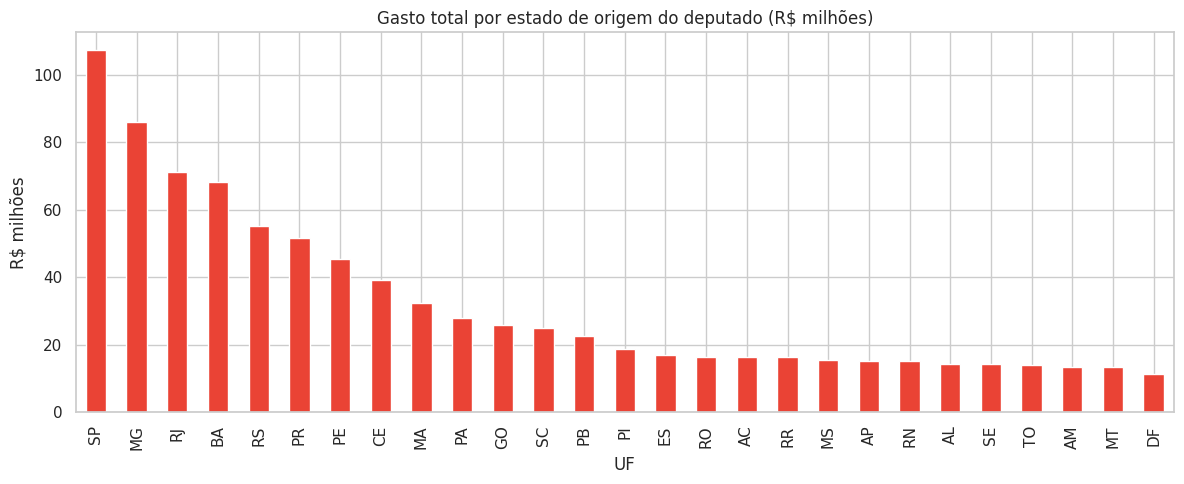

In [15]:
gasto_uf = (
    gastos.groupby("sguf")["vlrliquido"]
    .sum()
    .sort_values(ascending=False) / 1_000_000
)

ax = gasto_uf.plot(kind="bar", color="#EA4335", figsize=(12, 5))
ax.set_title("Gasto total por estado de origem do deputado (R$ milhões)")
ax.set_xlabel("UF")
ax.set_ylabel("R$ milhões")
plt.tight_layout()
plt.show()


## 9. Top 10 deputados por gasto total

In [16]:
top_deputados = (
    gastos.groupby(["txnomeparlamentar", "sgpartido", "sguf"])["vlrliquido"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_deputados


,,,vlrliquido
txnomeparlamentar,sgpartido,sguf,
Pompeo de Mattos,PDT,RS,2229624.51
Sidney Leite,PSD,AM,2197074.77
Cristiane Lopes,PODE,RO,2165464.00
Bibo Nunes,PL,RS,2150472.20
Silvia Cristina,PP,RO,2136205.23
Rodolfo Nogueira,PL,MS,2134665.17
Carlos Veras,PT,PE,2117190.56
Meire Serafim,UNIÃO,AC,2116832.17
Flávio Nogueira,PT,PI,2114154.58


## 10. Evolução mensal e outliers

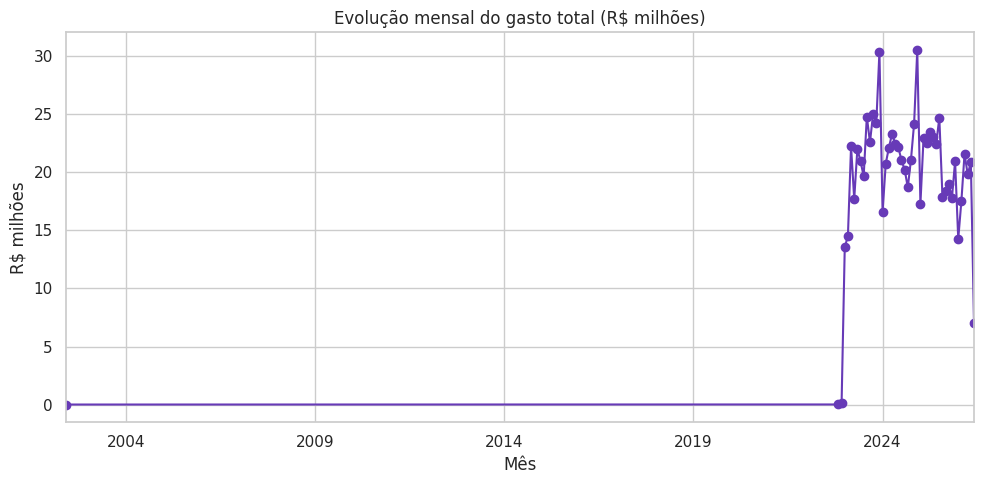

In [17]:
gastos["anomes"] = gastos["datemissao"].dt.to_period("M")
evolucao_mensal = gastos.groupby("anomes")["vlrliquido"].sum() / 1_000_000

ax = evolucao_mensal.plot(kind="line", marker="o", color="#673AB7")
ax.set_title("Evolução mensal do gasto total (R$ milhões)")
ax.set_xlabel("Mês")
ax.set_ylabel("R$ milhões")
plt.tight_layout()
plt.show()


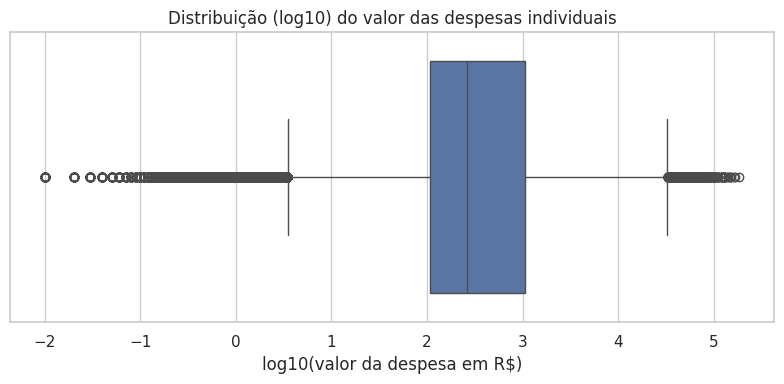

,txnomeparlamentar,sgpartido,sguf,txtdescricao,txtfornecedor,datemissao,vlrliquido
392608,Duda Ramos,PODE,RR,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,CESAR V. M. SANTANA EIRELI-ME,2024-12-30,184428.0
116685,Gustinho Ribeiro,PP,SE,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,Austregesilo Junior Aragão Melo,2023-12-29,164900.0
162233,Alexandre Guimarães,MDB,TO,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,GRÁFICA E EDITORA WR-EIRELI-ME,2023-12-14,163791.0
344928,Professor Alcides,PSDB,GO,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,Poligrafica Industria e Comercio Ltda,2024-12-27,150960.0
427040,Sargento Gonçalves,PL,RN,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,Maricleydson Costa da Silva,2024-12-27,149000.0
443612,Guilherme Uchoa,PSD,PE,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,STAMPA DIGITAL & MIDIA EXTERIOR LTDA,2024-12-30,148500.0
224169,Dal Barreto,UNIÃO,BA,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,ELMARA ROCHA DOS SANTOS NUNES LTDA,2023-10-24,140000.0
543675,Aluisio Mendes,REPUBLICANOS,MA,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,Adriano L Silva Engenharia Serviços e Comércio,2025-12-11,140000.0
82878,Aluisio Mendes,REPUBLICANOS,MA,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,Adriano L Silva Engenharia Serviços e Comércio,2023-11-06,130000.0
255871,Silas Câmara,REPUBLICANOS,AM,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,AMR COMERCIO DE ARTIGOS DE ESCRITÓRIOS E SERVI...,2024-10-15,130000.0


In [18]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=np.log10(gastos["vlrliquido"]))
plt.title("Distribuição (log10) do valor das despesas individuais")
plt.xlabel("log10(valor da despesa em R$)")
plt.tight_layout()
plt.show()

gastos.nlargest(10, "vlrliquido")[
    ["txnomeparlamentar", "sgpartido", "sguf", "txtdescricao", "txtfornecedor", "datemissao", "vlrliquido"]
]

## 11. Conclusões

*(Preencha com os principais insights depois de rodar com os dados reais — por exemplo: categoria que mais consome a cota, estado/partido com maior gasto médio por deputado, sazonalidade perto de datas-chave como recesso ou eleições, e outliers que merecem investigação manual.)*

**Possíveis próximos passos:**
- Calcular gasto **médio por deputado** (não só total), já que o número de deputados por UF/partido varia
- Cruzar com dados de **votos recebidos em 2022** para ver se há relação entre gasto e desempenho eleitoral
- Adicionar dados de **proposições e presença em votações** (também disponíveis na API da Câmara) para uma visão de produtividade vs. gasto
- Comparar com 1-2 Assembleias Legislativas estaduais, se os dados estiverem disponíveis em formato aberto
